In [5]:
import jax
print(jax.__version__)
print(jax.devices())

0.9.2
[CpuDevice(id=0)]


In [6]:
import json
import jax.numpy as jnp
import flax.linen as nn     # jax machine learning model package
import optax #jax optimizers packages


from functools import partial
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import plotly.graph_objects as go
from tqdm import tqdm
import numpy as np
from time import time

A way to reformulate the code to jit the functions. This isn't really optimal, Flax module will be used in the following.

In [7]:
def mySF1D_elementBased(x, left, right, training=False):
    # No register_buffer needed — JAX handles dtype promotion automatically
    # 'training' must be static (known at trace time) for jit to handle the if-branch correctly
    if training:
        x = (left + right) / 2.0
    
    sf1 = -(x - left) / (right - left) + 1.0
    sf2 =  (x - left) / (right - left)
    
    if training:
        return sf1, sf2, right - left, x
    else:
        return sf1, sf2

l, r = -0.9, 0.3

# jit the base function with training as a static compile-time flag
# static_argnames is the general pattern you'll reuse everywhere
mySF_jit = jax.jit(mySF1D_elementBased, static_argnames=('training',))

# Then freeze model parameters with partial — mimics "instantiating a model"
mySF = partial(mySF_jit, left=l, right=r)


In [8]:
XX = jnp.linspace(l, r , 100)
s1, s2 = mySF(XX)

fig = go.Figure()

fig.add_trace(go.Scatter(x=XX, y=s1, name='N1',    line=dict(color='#01426a')))

fig.add_trace(go.Scatter(x=XX, y=s2, name='N2', line=dict(color='#CE0037')))

fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    plot_bgcolor='rgba(0,0,0,0)',  # Remove background color
    width=700, 
    height=400,  
    xaxis=dict(title='x [mm]',
    showgrid=True,
    gridcolor='lightgray'),
    yaxis=dict(title='Shape functions',
    showgrid=True,
    gridcolor='lightgray',),    
    legend=dict(x=0, y=1, traceorder="normal")
)

fig.show()

## Vectorised version of the Element-based implementation

The shapes functions value constructor is purely fonctionnal, it doesn't have anything trainable so I guess I can turn it into mere functions and @jax.jit them.

In [9]:
@jax.jit
def GP():
    "Defines the position of the integration point(s) for the given element"
    return jnp.array([[1/2, 1/2]])    # coordonnés barycentriques

@jax.jit
def GetRefCoord(x, nodes_coord):
    # if nodes_coord.ndim == 2: nodes_coord = nodes_coord[:,:,None]
    
    InverseMapping          =  jnp.ones([int(nodes_coord.shape[0]), 2, 2])
    # print('nodes_coord', nodes_coord.shape)
    detJ                    = nodes_coord[:,0,0] - nodes_coord[:,1,0]
    InverseMapping = InverseMapping.at[:,0,1].set(- nodes_coord[:,1,0])
    InverseMapping = InverseMapping.at[:,1,1].set(nodes_coord[:,0,0])
    InverseMapping = InverseMapping.at[:,1,0].set(-1*InverseMapping[:,1,0])
    InverseMapping = InverseMapping.at[:,:,:].divide(detJ[:,None,None])
    # InverseMapping = InverseMapping / detJ[:, None, None]  
    x_extended = jnp.stack((x, jnp.ones_like(x)), axis=1)
    # print('x_extended',  x_extended.shape)

    return jnp.einsum('eij,ej...->ei',InverseMapping,x_extended)

@jax.jit
def UpdateConnectivity(connectivity):
    res = connectivity.astype(int) # marche aussi en jnp
    return res

def shape_functions(
            x               : jnp.array   = None  , 
            cell_id         : jnp.array   = None  , 
            coordinates     : jnp.array  = None  ,
            connectivity    : jnp.array = None ,
            flag_training   : bool          = False):

    GaussPoint = GP()
    w_g = jnp.array(1.0)
    
    assert coordinates is not None, "No nodes coordinates provided. Aborting"
    connectivity = UpdateConnectivity(connectivity)

    cell_nodes_IDs  = connectivity[cell_id,:]     # read only
    # print(cell_nodes_IDs)    
    Ids             = cell_nodes_IDs
    # print('\ntest',Ids)     
    nodes_coord     = coordinates[Ids]
    # print('nodes_coord shape',nodes_coord.shape)
    nodes_coord = nodes_coord.astype(GaussPoint.dtype)

    if flag_training: 
        refCoordg   = jnp.tile(GaussPoint, (cell_id.shape[0],1))
        Ng          = refCoordg
        # print('Ng shape', Ng.shape)                                     #valeurs des points des shapes functions au point de gauss
        x_g         = jnp.einsum('enx,en->ex',nodes_coord,Ng)     #coordonnées physiaue du point de gauss
        refCoord    = GetRefCoord(x_g,nodes_coord)
        N           = refCoord                                      # QUESTION : on doit retrouver les valeurs de shapes functions qui ont permis de transporter les points de Gauss, mais c etait justement pas points de depart ?
        detJ        = nodes_coord[:,1] - nodes_coord[:,0]
        return N, x_g, detJ*w_g


    else: 
        refCoord = GetRefCoord(x,nodes_coord)
        N = jnp.stack((refCoord[:,0], refCoord[:,1]), axis=1)       # on calcule les coordonnes du point a evaluer dans le mesh de reference 
        return N
    
shape_functions_jit = jax.jit(shape_functions, static_argnames=("flag_training",))

In [10]:
# a quick test
test = True
if test:
    x_test = jnp.array([1.75, 1.8, 2], dtype=jnp.float32)
    cell_id_test = jnp.array([0,0,1])
    coord_test = jnp.array([[1.],[2.],[3.]])
    connectivity_test = jnp.array([[0,1], [1,2], [2,3]])

    N = shape_functions_jit(x_test, cell_id_test, coord_test, connectivity_test, flag_training = False)
    print(N)

[[0.25       0.75      ]
 [0.20000005 0.79999995]
 [1.         0.        ]]


## Assembly using the vectorised element block

This time this is the real model instantiation so I have to use Flax to create a model class with trainables parameter. Contrary to Pytorch they will be managed outside of the class.

I turn the `__call__` function (equivalent of the `forward` method in `torch.nn.Module`) into a scalar input function and later use `jax.vmap()` to vectorize it and batch evaluate it. It requires to adapt some logic to be later jitted and vmapped. Especially the if, for and while statement among others.

In [11]:
class interpolation1D(nn.Module):
    nodes: jnp.ndarray
    elements: jnp.ndarray
    dirichlet: jnp.ndarray
    n_free: int
    n_components: int = 1

    def setup(self):
        self.Ne = len(self.elements)
        self.coordinates = self.nodes
        
        self.dofs_free = jnp.ones(self.nodes.shape[0], dtype=bool).at[self.dirichlet].set(False)
        
        self.nodal_values_free = self.param(
            'nodal_values_free',
            lambda rng, shape: jnp.ones(shape) * 0.5,
            (self.n_free, self.n_components)
        )
        
        self.nodal_values_imposed = jnp.zeros((self.nodes.shape[0], self.n_components))

    def _assemble_nodal_values(self):
        """Fully traceable assembly using cumsum indexing"""
        cumsum_free = jnp.cumsum(self.dofs_free) - 1
        
        return jnp.where(
            self.dofs_free[:, None],
            self.nodal_values_free[cumsum_free], # this way, the cumsum create a map to make nodal_values_free appear the right length
            self.nodal_values_imposed
        )

    def find_element_vmapped(self, x_scalar):
        x_left = self.coordinates[self.elements[:, 0]]
        x_right = self.coordinates[self.elements[:, 1]]
        in_element = (x_scalar >= x_left) & (x_scalar <= x_right)
        k_elt = jnp.argmax(in_element)
        return k_elt

    def __call__(self, x_scalar):
        k_elt = self.find_element_vmapped(x_scalar)
        
        shape_functions = shape_functions_jit(
            x=jnp.array([x_scalar]),
            cell_id=jnp.array([k_elt]),
            coordinates=self.nodes,
            connectivity=self.elements,
            flag_training=False
        )
        
        nodal_values_tensor = self._assemble_nodal_values()
        
        cell_nodes_IDs = self.elements[k_elt, :]
        nodes_values = nodal_values_tensor[cell_nodes_IDs]
        nodes_values = nodes_values.astype(shape_functions.dtype)
        
        shape_functions = shape_functions[0, :]
        nodes_values = nodes_values[:, 0]
        
        u = jnp.dot(nodes_values, shape_functions)
        return u

#### Initializer function

In [12]:
def initialize_model(nodes, elements):
    n              = nodes.shape[0]
    dirichlet_test = jnp.array([0, n-1])
    n_free = n - len(dirichlet_test)
    x_test = jnp.array(1., dtype=jnp.float32)
    """Initialize model, parameters, and optimizer"""
    model = interpolation1D(
        nodes=nodes,
        elements=elements,
        dirichlet=dirichlet_test,
        n_free=n_free
    )
    
    key = jax.random.key(0)
    params = model.init(key, x_test)
    # print("params ", params)
    
    u = model.apply(params, x_test)
    # print("u =", u)
    
    optim = optax.adam(learning_rate=1)
    opt_state = optim.init(params)
    
    return model, params, optim, opt_state


#### Define the training function and loss

In [13]:
@jax.jit
def PotentialEnergy(params):
    x_dummy = jnp.array([0.], dtype=jnp.float32)
    cell_id_all = jnp.arange(0, len(elements)) # all the elements
    _, x_g, J = shape_functions_jit(x = x_dummy, 
                                    cell_id = cell_id_all,
                                    coordinates = nodes,
                                    connectivity = elements,
                                    flag_training = True)
    # print(u_vals.shape)
    # print(x_g.shape)
    # assert u_vals.shape == x_g.shape

    # differentiate u w.r.t. x_g directly
    def u_fn(x_scalar):
        u = model.apply(params, x_scalar)
        return u 

    # vmap and grad compose cleanly outside
    u_xg = jax.vmap(u_fn)(x_g)
    du_dx_xg  = jax.vmap(jax.grad(u_fn))(x_g)

    int_term1 = 0.5 * du_dx_xg * du_dx_xg * J
    int_term2 = f(x_g) * J * u_xg
    return jnp.sum(int_term1 - int_term2)

@jax.jit
def f(x):
    return 1000 #-x*(x-10)

In [14]:
## train step

@jax.jit
def train_step(params, opt_state):
    # Calcul de la loss et de son gradient, the loss function is the potential energy here
    loss, grads = jax.value_and_grad(PotentialEnergy)(params)

    # Optimizer step
    updates, new_opt_state = optim.update(grads, opt_state) # you need to provide him grads : the loss gradients w.r.t the params
    
    #Update the weights
    params = optax.apply_updates(params, updates)

    return params, new_opt_state, loss

#### Initialize and train

In [15]:
# Mesh generation
N           = 50
nodes       = jnp.linspace(0,6.28,N)
nodes       = nodes[:,None] # pq il l etend ? pour être dim 2
elements    = jnp.vstack([jnp.arange(0,N-1),jnp.arange(1,N)]).T

#Initialization
model, params, optim, opt_state = initialize_model(nodes, elements)

#training
N_epoch = 10000
lossList = []
lossTraining = []

start_time = time()

for epoch in tqdm(range(N_epoch)):
    params, opt_state, loss = train_step(params, opt_state)
    lossTraining.append(loss)

end_time = time()

elapsed_time = end_time - start_time

print(f"\n{'='*50}")
print(f"Total training time: {elapsed_time:.2f} seconds")
print(f"Time per epoch: {elapsed_time / N_epoch * 1000:.2f} ms")
print(f"{'='*50}")

100%|██████████| 10000/10000 [00:00<00:00, 13216.73it/s]


Total training time: 0.78 seconds
Time per epoch: 0.08 ms


## Post-processing

In [16]:
#| code-fold: true

# plt.figure()
# plt.plot(lossTraining)
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.show()

fig = go.Figure()


fig.add_trace(go.Scatter(y=lossTraining, mode='lines+markers', name='du/dx', line=dict(color='#01426a')
))

fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    plot_bgcolor='rgba(0,0,0,0)',  # Remove background color
    width=700, 
    height=400,  
    xaxis=dict(title='Epochs',
    showgrid=True,
    gridcolor='lightgray'),
    yaxis=dict(title='Loss',
    tickvals=[-4.022e8, -4.016e8, -4.008e8],
    ticktext=['-4.022e8', '-4.016e8', '-4.008e8'],
    showgrid=True,
    gridcolor='lightgray',),
)

fig.show()

In [17]:
#| code-fold: true
x_dummy = jnp.array([0.], dtype=jnp.float32)
cell_id_all = jnp.arange(0, len(elements)) # all the elements
_, x_g, J = shape_functions_jit(x = x_dummy, 
                                cell_id = cell_id_all,
                                coordinates = nodes,
                                connectivity = elements,
                                flag_training = True)


def u_fn(x_scalar):
        u = model.apply(params, x_scalar)
        return u

u_g = jax.vmap(u_fn)(x_g)

# print(x_g)
# print(u_g)

x_test = jnp.linspace(0,6.28,30)
u_eval = jax.vmap(u_fn)(x_test)
# print(u_eval)

# plt.figure()
# plt.plot(x_g.data,u.data, '+',label='Gauss points')
# plt.plot(x_test.data,u_eval.data, 'o',label='Test points')
# plt.xlabel("x [mm]")
# plt.ylabel("u(x) [mm]")
# plt.legend()
# plt.show() 

fig = go.Figure()


fig.add_trace(go.Scatter(
    x=np.asarray(x_g[:,0]), 
    y=np.asarray(u_g),  # Convert JAX array to NumPy
    mode='markers', 
    marker=dict(symbol='circle'), 
    name='Gauss points', 
    line=dict(color='#01426a')
))

fig.add_trace(go.Scatter(
    x=np.asarray(x_test), 
    y=np.asarray(u_eval),  # Convert JAX array to NumPy
    mode='markers', 
    marker=dict(symbol='cross'), 
    name='Test points', 
    line=dict(color='#CE0037')
))

fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    plot_bgcolor='rgba(0,0,0,0)',  # Remove background color
    width=700, 
    height=400,  
    xaxis=dict(title='x [mm]',
    showgrid=True,
    gridcolor='lightgray'),
    yaxis=dict(title='u(x) [mm]',
    showgrid=True,
    gridcolor='lightgray',),    
    legend=dict(x=0, y=1, traceorder="normal")
)

## Benchmarking

In [24]:
def run_single_benchmark_verbose(N, N_epoch):
    """Run a single benchmark with mesh size N and N_epoch epochs"""
    
    print(f"\n{'='*60}")
    print(f"BENCHMARK: N = {N}, N_epoch = {N_epoch}")
    print(f"{'='*60}")
    
    # Mesh generation
    print(f"[1/6] Generating mesh...")
    nodes = jnp.linspace(0, 6.28, N)
    nodes = nodes[:, None]
    elements = jnp.vstack([jnp.arange(0, N-1), jnp.arange(1, N)]).T
    
    print(f"  nodes shape: {nodes.shape}")
    print(f"  elements shape: {elements.shape}")
    print(f"  n_elements: {len(elements)}")
    
    ## Gauss points and J computation for that mesh
    print(f"[2/6] Computing shape functions...")
    x_dummy = jnp.array([0.], dtype=jnp.float32)
    cell_id_all = jnp.arange(0, len(elements))
    
    shape_start = time()
    _, x_g, J = shape_functions_jit(x=x_dummy, 
                                     cell_id=cell_id_all,
                                     coordinates=nodes,
                                     connectivity=elements,
                                     flag_training=True)
    shape_time = time() - shape_start
    
    print(f"  Shape function computation: {shape_time:.3f}s")
    print(f"  x_g shape: {x_g.shape}, dtype: {x_g.dtype}")
    print(f"  J shape: {J.shape}, dtype: {J.dtype}")
    print(f"  x_g size: {x_g.nbytes / 1024**2:.2f} MB")
    print(f"  J size: {J.nbytes / 1024**2:.2f} MB")
    
    # Initialization
    print(f"[3/6] Initializing model...")
    model, params, optim, opt_state = initialize_model(nodes, elements)
    
    # Count parameters
    param_count = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"  Model parameters: {param_count:,}")
    
    # Check GPU/CPU
    print(f"[4/6] Device info...")
    print(f"  JAX devices: {jax.devices()}")
    print(f"  Default backend: {jax.default_backend()}")
    
    try:
        device = jax.devices()[0]
        if hasattr(device, 'memory_stats'):
            mem_stats = device.memory_stats()
            print(f"  Device memory stats: {mem_stats}")
    except Exception as e:
        print(f"  Could not get memory stats: {e}")
    
    # Define JIT functions
    @jax.jit
    def PotentialEnergy_local(params):
        def u_fn(x_scalar):
            u = model.apply(params, x_scalar)
            return u 
        
        # differentiate u w.r.t. x_g directly
        u_xg = jax.vmap(u_fn)(x_g)
        du_dx_xg = jax.vmap(jax.grad(u_fn))(x_g)
        int_term1 = 0.5 * du_dx_xg * du_dx_xg * J
        int_term2 = f(x_g) * J * u_xg
        return jnp.sum(int_term1 - int_term2)
    
    @jax.jit
    def train_step_local(params, opt_state):
        loss, grads = jax.value_and_grad(PotentialEnergy_local)(params)
        updates, new_opt_state = optim.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss
    
    # Profile individual operations
    print(f"[5/6] Profiling components...")
    
    @jax.jit
    def just_forward(params):
        def u_fn(x_scalar):
            return model.apply(params, x_scalar)
        return jax.vmap(u_fn)(x_g)
    
    @jax.jit
    def just_gradient(params):
        def u_fn(x_scalar):
            return model.apply(params, x_scalar)
        return jax.vmap(jax.grad(u_fn))(x_g)
    
    @jax.jit
    def just_energy(params):
        return PotentialEnergy_local(params)
    
    # Warmup and profile
    print(f"  Compiling forward pass...")
    fwd_compile_start = time()
    _ = just_forward(params).block_until_ready()
    fwd_compile_time = time() - fwd_compile_start
    print(f"    Compile time: {fwd_compile_time:.3f}s")
    
    fwd_start = time()
    _ = just_forward(params).block_until_ready()
    fwd_time = time() - fwd_start
    print(f"    Execution time: {fwd_time*1000:.2f}ms")
    
    print(f"  Compiling gradient pass...")
    grad_compile_start = time()
    _ = just_gradient(params).block_until_ready()
    grad_compile_time = time() - grad_compile_start
    print(f"    Compile time: {grad_compile_time:.3f}s")
    
    grad_start = time()
    _ = just_gradient(params).block_until_ready()
    grad_time = time() - grad_start
    print(f"    Execution time: {grad_time*1000:.2f}ms")
    
    print(f"  Compiling energy computation...")
    energy_compile_start = time()
    _ = just_energy(params)
    energy_compile_time = time() - energy_compile_start
    print(f"    Compile time: {energy_compile_time:.3f}s")
    
    energy_start = time()
    _ = just_energy(params)
    energy_time = time() - energy_start
    print(f"    Execution time: {energy_time*1000:.2f}ms")
    
    # Warmup training step
    print(f"[6/6] Warming up training step...")
    warmup_start = time()
    params, opt_state, loss = train_step_local(params, opt_state)
    loss.block_until_ready()  # Ensure completion
    warmup_time = time() - warmup_start
    print(f"  Full training step warmup: {warmup_time:.3f}s")
    print(f"  Initial loss: {loss:.6f}")
    
    # Run a few training steps to get stable timing
    print(f"\n  Running 10 warmup epochs for timing...")
    warmup_times = []
    for i in range(10):
        step_start = time()
        params, opt_state, loss = train_step_local(params, opt_state)
        loss.block_until_ready()
        step_time = time() - step_start
        warmup_times.append(step_time)
        print(f"    Warmup epoch {i}: {step_time*1000:.2f}ms, loss: {loss:.6f}")
    
    print(f"  Mean warmup time: {np.mean(warmup_times)*1000:.2f}ms ± {np.std(warmup_times)*1000:.2f}ms")
    
    # ACTUAL TIMING
    print(f"\nStarting full benchmark ({N_epoch} epochs)...")
    lossTraining = []
    epoch_times = []
    
    start_time = time()
    
    for epoch in tqdm(range(N_epoch), desc=f"N={N}", leave=False):
        epoch_start = time()
        params, opt_state, loss = train_step_local(params, opt_state)
        loss.block_until_ready()  # Ensure GPU completion
        epoch_time = time() - epoch_start
        
        epoch_times.append(epoch_time)
        lossTraining.append(float(loss))
    
    end_time = time()
    elapsed_time = end_time - start_time
    time_per_epoch = elapsed_time / N_epoch * 1000
    
    # Summary statistics
    print(f"\n{'='*60}")
    print(f"RESULTS for N={N}:")
    print(f"  Total time: {elapsed_time:.2f}s")
    print(f"  Time per epoch: {time_per_epoch:.2f}ms")
    print(f"  Mean epoch time: {np.mean(epoch_times)*1000:.2f}ms")
    print(f"  Std epoch time: {np.std(epoch_times)*1000:.2f}ms")
    print(f"  Min epoch time: {np.min(epoch_times)*1000:.2f}ms")
    print(f"  Max epoch time: {np.max(epoch_times)*1000:.2f}ms")
    print(f"  Final loss: {lossTraining[-1]:.6f}")
    print(f"  Throughput: {N_epoch/elapsed_time:.2f} epochs/sec")
    print(f"{'='*60}\n")
    
    return {
        'mesh_size': N,
        'n_epochs': N_epoch,
        'total_time': elapsed_time,
        'time_per_epoch_ms': time_per_epoch,
        'losses': np.array(lossTraining),
        'epoch_times': np.array(epoch_times),
        'diagnostics': {
            'shape_function_time': shape_time,
            'forward_compile_time': fwd_compile_time,
            'forward_exec_time': fwd_time,
            'gradient_compile_time': grad_compile_time,
            'gradient_exec_time': grad_time,
            'energy_compile_time': energy_compile_time,
            'energy_exec_time': energy_time,
            'warmup_train_step': warmup_time,
            'x_g_shape': x_g.shape,
            'J_shape': J.shape,
            'n_params': param_count,
        }
    }

def run_single_benchmark(N, N_epoch):
    """Run a single benchmark with mesh size N and N_epoch epochs"""
    
    # Mesh generation
    nodes = jnp.linspace(0, 6.28, N)
    nodes = nodes[:, None]
    elements = jnp.vstack([jnp.arange(0, N-1), jnp.arange(1, N)]).T
    
    ## Gauss points and J computation for that mesh
    x_dummy = jnp.array([0.], dtype=jnp.float32)
    cell_id_all = jnp.arange(0, len(elements)) # all the elements
    _, x_g, J = shape_functions_jit(x = x_dummy, 
                                    cell_id = cell_id_all,
                                    coordinates = nodes,
                                    connectivity = elements,
                                    flag_training = True)
    
    # Initialization
    model, params, optim, opt_state = initialize_model(nodes, elements)
    @jax.jit
    def PotentialEnergy_local(params):
        def u_fn(x_scalar):
            u = model.apply(params, x_scalar)
            return u 

        # differentiate u w.r.t. x_g directly
        u_xg = jax.vmap(u_fn)(x_g)
        du_dx_xg  = jax.vmap(jax.grad(u_fn))(x_g)

        int_term1 = 0.5 * du_dx_xg * du_dx_xg * J
        int_term2 = f(x_g) * J * u_xg
        return jnp.sum(int_term1 - int_term2)

    @jax.jit
    def train_step_local(params, opt_state):
        loss, grads = jax.value_and_grad(PotentialEnergy_local)(params)
        updates, new_opt_state = optim.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss
    

    params, opt_state, loss = train_step_local(params, opt_state)
    # ACTUAL TIMING
    lossTraining = []
    epoch_times = []

    start_time = time()
    for epoch in tqdm(range(N_epoch)):
        epoch_start = time()
        params, opt_state, loss = train_step_local(params, opt_state)
        epoch_time = time() - epoch_start
        
        epoch_times.append(epoch_time)
        lossTraining.append(loss)
    
    end_time = time()
    elapsed_time = end_time - start_time
    time_per_epoch = elapsed_time / N_epoch * 1000
    
    return {
        'mesh_size': N,
        'n_epochs': N_epoch,
        'total_time': elapsed_time,
        'time_per_epoch_ms': time_per_epoch,
        'losses': np.array(lossTraining)
    }

def benchmark_mesh_scaling(mesh_sizes, N_epoch=1000, verbose = False):
    """Benchmark over different mesh sizes"""
    results = []
    
    print("\n" + "="*60)
    print("BENCHMARKING: Scaling with Mesh Size")
    print("="*60)
    if verbose: bench_fn = run_single_benchmark_verbose
    else : bench_fn = run_single_benchmark

    for N in mesh_sizes:
        result = bench_fn(N, N_epoch)
        results.append(result)
        print(f"\nMesh size N={N:4d} | Total time: {result['total_time']:7.2f}s | Per epoch: {result['time_per_epoch_ms']:6.2f}ms")
    
    return results

def benchmark_epoch_scaling(N, epoch_counts):
    """Benchmark over different epoch counts"""
    results = []
    
    print("\n" + "="*60)
    print(f"BENCHMARKING: Scaling with Epoch Count (Mesh size N={N})")
    print("="*60)
    
    for n_epoch in epoch_counts:
        result = run_single_benchmark(N, n_epoch)
        results.append(result)
        print(f"\nEpochs {n_epoch:5d} | Total time: {result['total_time']:7.2f}s | Per epoch: {result['time_per_epoch_ms']:6.2f}ms")
    
    return results

def plot_time_vs_mesh(mesh_results):
    mesh_sizes = np.array([r['mesh_size'] for r in mesh_results])
    total_times = np.array([r['total_time'] for r in mesh_results])

    plt.figure(figsize=(6, 4))
    
    plt.plot(mesh_sizes, total_times, 'o-', linewidth=2, label='Measured')

    # # Use last point for normalization (more stable)
    # ref_linear = total_times[-1] * (mesh_sizes / mesh_sizes[-1])
    # plt.plot(mesh_sizes, ref_linear, '--', linewidth=2, label='O(N)')

    plt.xlabel('Mesh Size (N)')
    plt.ylabel('Total Training Time (s)')
    plt.title('Total Time vs Mesh Size')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

def export_time_vs_mesh(results, filepath):
    """
    Extract mesh_size and total_time from results and save as JSON.

    Parameters
    ----------
    results : list of dict
        Your experiment list
    filepath : str
        Output JSON file path
    """
    filtered = [
        {
            "mesh_size": int(r["mesh_size"]),  # ensure JSON serializable
            "total_time": float(r["total_time"])
        }
        for r in results
    ]

    with open(filepath, "w") as f:
        json.dump(filtered, f, indent=4)

def plot_multiple_time_vs_mesh(filepaths, labels=None, loglog=False):
    """
    Load multiple JSON files and plot them on a unified mesh_size axis.

    Parameters
    ----------
    filepaths : list of str
        Paths to JSON files
    labels : list of str (optional)
        Labels for each dataset
    loglog : bool
        Use log-log scale
    """
    all_data = []
    all_mesh_sizes = set()

    # Load all datasets
    for fp in filepaths:
        with open(fp, "r") as f:
            data = json.load(f)

        mesh = np.array([d["mesh_size"] for d in data])
        time = np.array([d["total_time"] for d in data])

        all_data.append((mesh, time))
        all_mesh_sizes.update(mesh)

    # Unified sorted mesh axis
    unified_mesh = np.array(sorted(all_mesh_sizes))

    plt.figure()

    # Plot each dataset aligned on unified axis
    for i, (mesh, time) in enumerate(all_data):
        # Create aligned array with NaNs for missing points
        aligned_time = np.full_like(unified_mesh, np.nan, dtype=float)

        # Fill values where available
        for m, t in zip(mesh, time):
            idx = np.where(unified_mesh == m)[0][0]
            aligned_time[idx] = t

        label = labels[i] if labels else f"run_{i}"
        plt.plot(unified_mesh, aligned_time, marker='o', label=label)

    if loglog:
        plt.xscale("log")
        plt.yscale("log")

    plt.xlabel("Mesh size")
    plt.ylabel("Total training time (s)")
    plt.title("Training time vs Mesh size\nJax vs Pytorch on CPU")
    plt.grid(True)
    plt.legend()

    plt.show()

In [19]:
mesh_sizes = np.array([20, 50, 100, 200, 300,400, 500, 600, 700, 800, 900, 1000, 1025])
epochs_per_mesh = 10000

# Run benchmarks
mesh_results = benchmark_mesh_scaling(mesh_sizes, N_epoch=epochs_per_mesh)


BENCHMARKING: Scaling with Mesh Size


100%|██████████| 10000/10000 [00:00<00:00, 25350.93it/s]



Mesh size N=  20 | Total time:    0.40s | Per epoch:   0.04ms


100%|██████████| 10000/10000 [00:00<00:00, 20116.39it/s]



Mesh size N=  50 | Total time:    0.50s | Per epoch:   0.05ms


...


Mesh size N= 900 | Total time:    6.76s | Per epoch:   0.68ms


100%|██████████| 10000/10000 [00:08<00:00, 1181.60it/s]



Mesh size N=1000 | Total time:    8.46s | Per epoch:   0.85ms


100%|██████████| 10000/10000 [00:08<00:00, 1159.40it/s]



Mesh size N=1025 | Total time:    8.63s | Per epoch:   0.86ms


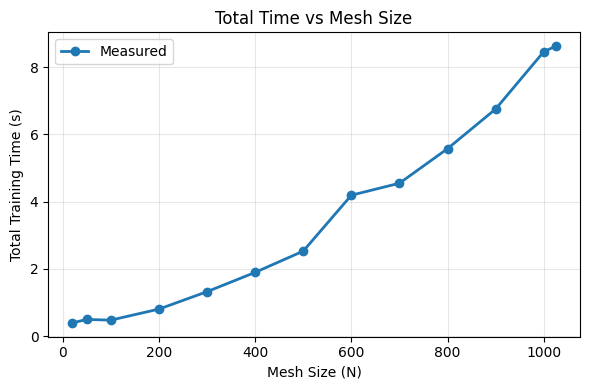

In [20]:
plot_time_vs_mesh(mesh_results)
export_time_vs_mesh(mesh_results, "time_vs_mesh_jax.json")

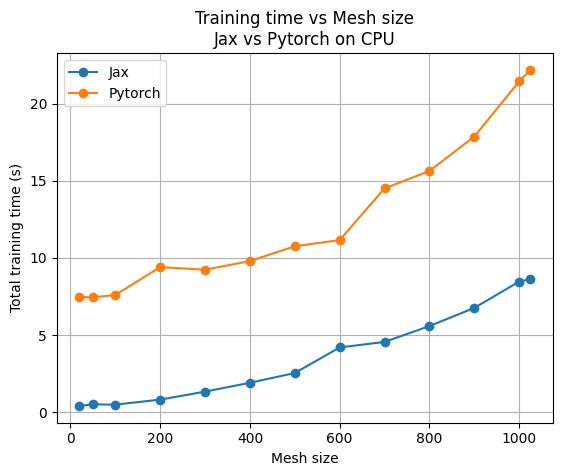

In [25]:
plot_multiple_time_vs_mesh(
    ["time_vs_mesh_jax.json", "time_vs_mesh_pytorch.json"],
    labels=["Jax", "Pytorch"]
)

#### Change of behavior at n_elements = 1024

In [26]:
# Compare N=1025 vs N=1026
result_1025 = run_single_benchmark_verbose(1025, 5000)
result_1026 = run_single_benchmark_verbose(1026, 5000)



BENCHMARK: N = 1025, N_epoch = 5000
[1/6] Generating mesh...
  nodes shape: (1025, 1)
  elements shape: (1024, 2)
  n_elements: 1024
[2/6] Computing shape functions...
  Shape function computation: 0.000s
  x_g shape: (1024, 1), dtype: float32
  J shape: (1024, 1), dtype: float32
  x_g size: 0.00 MB
  J size: 0.00 MB
[3/6] Initializing model...
  Model parameters: 1,023
[4/6] Device info...
  JAX devices: [CpuDevice(id=0)]
  Default backend: cpu
  Device memory stats: None
[5/6] Profiling components...
  Compiling forward pass...
    Compile time: 0.126s
    Execution time: 0.34ms
  Compiling gradient pass...
    Compile time: 0.102s
    Execution time: 0.37ms
  Compiling energy computation...
    Compile time: 0.131s
    Execution time: 0.03ms
[6/6] Warming up training step...
  Full training step warmup: 0.467s
  Initial loss: -3167146.500000

  Running 10 warmup epochs for timing...
    Warmup epoch 0: 1.16ms, loss: -8925760.000000
    Warmup epoch 1: 0.87ms, loss: -15405484.000000


RESULTS for N=1025:
  Total time: 4.40s
  Time per epoch: 0.88ms
  Mean epoch time: 0.87ms
  Std epoch time: 0.08ms
  Min epoch time: 0.78ms
  Max epoch time: 1.50ms
  Final loss: -6227338752.000000
  Throughput: 1135.66 epochs/sec


BENCHMARK: N = 1026, N_epoch = 5000
[1/6] Generating mesh...
  nodes shape: (1026, 1)
  elements shape: (1025, 2)
  n_elements: 1025
[2/6] Computing shape functions...
  Shape function computation: 0.000s
  x_g shape: (1025, 1), dtype: float32
  J shape: (1025, 1), dtype: float32
  x_g size: 0.00 MB
  J size: 0.00 MB
[3/6] Initializing model...
  Model parameters: 1,024
[4/6] Device info...
  JAX devices: [CpuDevice(id=0)]
  Default backend: cpu
  Device memory stats: None
[5/6] Profiling components...
  Compiling forward pass...
    Compile time: 0.093s
    Execution time: 0.43ms
  Compiling gradient pass...
    Compile time: 0.100s
    Execution time: 0.36ms
  Compiling energy computation...
    Compile time: 0.138s
    Execution time: 0.03ms
[6/6] Warm


RESULTS for N=1026:
  Total time: 18.56s
  Time per epoch: 3.71ms
  Mean epoch time: 3.67ms
  Std epoch time: 0.63ms
  Min epoch time: 3.27ms
  Max epoch time: 39.92ms
  Final loss: -6219370496.000000
  Throughput: 269.46 epochs/sec



With the help of Claude, I pinpointed the issue. Due to this running on CPU only, there is a change of behavior around $2ˆ10 = 1024$. 
Claude tells me this :

    Why the Sudden Slowdown at N=1050
    On CPU, JAX uses different BLAS/LAPACK routines depending on matrix sizes. There are common performance cliffs at powers of 2:

    N ≤ 1024 (2^10): Uses optimized cache-friendly algorithms
    N > 1024: Switches to different algorithm, loses cache efficiency
